<a href="https://colab.research.google.com/github/akulbajpai-code/Cyberbullying-Detection-with-Teenage-Slang-/blob/main/CyberbullyingDetectionCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

# ==========================================
# CORRECT PATH FOR DIRECT UPLOADS
# ==========================================
base_path = '/content/'

files = [
    "attack_annotated_comments.tsv",
    "attack_annotations.tsv",
    "labeled_data.csv",
    "aggression_parsed_dataset.csv",
    "attack_parsed_dataset.csv",
    "cyberbullying_tweets.csv",
    "kaggle_parsed_dataset.csv",
    "toxicity_parsed_dataset.csv",
    "twitter_parsed_dataset.csv",
    "twitter_racism_parsed_dataset.csv",
    "twitter_sexism_parsed_dataset.csv", # I added .csv here, assuming it has one
    "youtube_parsed_dataset.csv"
]

print("--- DATASET INSPECTION REPORT ---")

for filename in files:
    file_path = os.path.join(base_path, filename)
    print(f"\n==========================================")
    print(f"ANALYZING: {filename}")

    if not os.path.exists(file_path):
        # Try checking without the extension just in case
        if os.path.exists(file_path.replace('.csv', '')):
             file_path = file_path.replace('.csv', '')
        else:
            print(f"ERROR: File not found at {file_path}")
            continue

    try:
        # 1. Try reading as TSV (Tab Separated)
        if 'tsv' in filename:
            df = pd.read_csv(file_path, sep='\t', nrows=5)
        # 2. Try reading as standard CSV
        else:
            try:
                df = pd.read_csv(file_path, nrows=5)
            except:
                # 3. Fallback for Latin-1 encoding (common in older datasets)
                df = pd.read_csv(file_path, nrows=5, encoding='latin1')

        print(f"COLUMNS: {list(df.columns)}")
        print("FIRST ROW SAMPLE:")
        # Print just the first row values to see what the data looks like
        print(df.iloc[0].to_dict())

    except Exception as e:
        print(f"FAILED TO READ: {e}")

print("\n==========================================")
print("DONE. Please copy and paste this output.")

--- DATASET INSPECTION REPORT ---

ANALYZING: attack_annotated_comments.tsv
COLUMNS: ['rev_id', 'comment', 'year', 'logged_in', 'ns', 'sample', 'split']
FIRST ROW SAMPLE:
{'rev_id': 37675, 'comment': "`-NEWLINE_TOKENThis is not ``creative``.  Those are the dictionary definitions of the terms ``insurance`` and ``ensurance`` as properly applied to ``destruction``.  If you don't understand that, fine, legitimate criticism, I'll write up ``three man cell`` and ``bounty hunter`` and then it will be easy to understand why ``ensured`` and ``insured`` are different - and why both differ from ``assured``.NEWLINE_TOKENNEWLINE_TOKENThe sentence you quote is absolutely neutral.  You just aren't familiar with the underlying theory of strike-back (e.g. submarines as employed in nuclear warfare) guiding the insurance, nor likely the three man cell structure that kept the IRA from being broken by the British.  If that's my fault, fine, I can fix that to explain.  But ther'es nothing ``personal`` or ``

In [ ]:
# ==========================================
# PART 1: INSTALL LIBRARIES & SETUP
# ==========================================
!pip install langdetect

import pandas as pd
import numpy as np
import re
import os
from langdetect import detect, DetectorFactory

# Fix randomness for consistent results
DetectorFactory.seed = 0

# Base path (Current directory in Colab)
base_path = '/content/'

# ==========================================
# PART 2: DEFINE SLANG DICTIONARY & FILTERS
# ==========================================

# Your specific dictionary
slang_dict = {
    "tf": "i am extremely surprised", "kys": "I hate you", "stfu": "shut up",
    "wth": "i am extremely surprised", "idgaf": "i do not care", "fml": "my life is terrible",
    "af": "extremely", "kms": "i am miserable", "btfo": "completely defeated",
    "lmfao": "laughing hard", "asf": "very", "clown": "fool", "wrecked": "destroyed",
    "bodied": "dominated", "cooked": "finished", "crash out": "lose temper", "zero chill": "no restraint",
    "wildin": "acting crazy", "tweaking": "acting irrational", "shiz": "junk", "bss": "nonsense",
    "effing": "extremely", "rizz": "charisma", "rizzler": "charismatic person", "gyatt": "surprise",
    "skibidi": "bad", "sigma": "cool", "fanum tax": "stealing food", "mewing": "jawline exercise",
    "looksmaxxing": "improving appearance", "delulu": "delusional", "solulu": "solution",
    "ohio": "weird", "mog": "outshine", "ratio": "outvoted", "goofy ahh": "goofy",
    "pookie": "dear", "aura": "presence", "glazing": "over-praising", "no cap": "no lie",
    "cap": "lie", "bet": "agree", "slay": "did well", "ate": "did great", "no crumbs": "perfectly",
    "sus": "suspicious", "finna": "going to", "lowkey": "secretly", "highkey": "openly",
    "shook": "shocked", "vibe": "mood", "tea": "gossip", "mid": "average", "clout": "influence",
    "fire": "amazing", "lit": "exciting", "bop": "good song", "cheugy": "outdated", "flex": "show off",
    "rent free": "obsessed", "it is giving": "it resembles", "sending me": "funny",
    "gagged": "shocked", "serving": "looking good", "ick": "disgust", "red flag": "warning sign",
    "beige flag": "boring trait", "ghost": "stop replying", "curving": "rejecting",
    "breadcrumbing": "leading on", "gaslight": "manipulate", "gatekeep": "restrict access",
    "girlboss": "ambitious person", "touch grass": "go outside", "unalive": "kill",
    "opps": "enemies", "bag": "money", "fumbled": "messed up", "receipts": "evidence",
    "npc": "boring person", "canon event": "inevitable event", "side quest": "distraction",
    "locked in": "focused", "washed": "past prime", "clutch": "performing under pressure",
    "dub": "win", "deadass": "seriously", "no diff": "easy win", "zesty": "bold", "doomer": "pessimist",
    "bloomer": "optimist", "yeet": "throw", "bussin": "good", "caught in 4k": "caught on camera",
    "ceo": "expert", "cringe": "embarrassing", "drip": "style", "gigachad": "ideal person",
    "goat": "greatest", "ijbol": "laughing", "munch": "obsessed person", "savage": "ruthless",
    "shade": "insult", "ship": "support a couple", "snack": "attractive person", "snatched": "perfect",
    "vibe check": "mood assessment", "valid": "good", "mood": "relatable", "fomo": "fear of missing out",
    "baddie": "attractive person", "karen": "entitled person", "boujee": "fancy", "hype": "energy",
    "chill": "calm", "fr": "for real", "idk": "i do not know", "idc": "i do not care", "nvm": "never mind",
    "tbh": "to be honest", "ttyl": "talk to you later", "asap": "as soon as possible", "btw": "by the way",
    "fyi": "for your information", "hmu": "hit me up", "wbu": "what about you", "wyd": "what you doing",
    "yolo": "you only live once", "dm": "direct message", "ig": "i guess", "tldr": "summary", "bc": "because",
    "dw": "do not worry", "gtg": "got to go", "hbd": "happy birthday", "icymi": "in case you missed it",
    "iirc": "if i recall correctly", "istg": "i swear to god", "iykyk": "if you know you know", "nbd": "no big deal",
    "otw": "on the way", "smh": "shaking my head", "tba": "to be announced", "tbd": "to be determined",
    "thx": "thanks", "ty": "thank you", "yw": "you are welcome", "rn": "right now", "fav": "favorite",
    "vid": "video", "def": "definitely", "prob": "probably", "cuz": "because", "gon": "going to",
    "wanna": "want to", "gotta": "got to", "tmr": "tomorrow", "msg": "message", "txt": "text",
    "brb": "be right back", "bff": "best friend", "lmao": "laughing", "lol": "laughing", "omg": "oh my god",
    "pov": "point of view", "jk": "just kidding", "asl": "age sex location", "atp": "at this point",
    "cba": "can not be bothered", "tbf": "to be fair", "tbt": "throwback thursday", "tfw": "that feeling when",
    "oomf": "one of my followers", "rofl": "laughing", "tia": "thanks in advance", "tmi": "too much information",
    "xoxo": "hugs and kisses", "ootd": "outfit of the day", "mfw": "my face when", "til": "today i learned",
    "wfh": "work from home", "moots": "mutual friends", "simping": "overly devoted", "stan": "fan",
    "fit": "outfit", "glow up": "improvement", "ghosted": "ignored", "salty": "bitter", "extra": "dramatic",
    "fam": "community", "purr": "approval", "aggro": "aggressive", "nerf": "weaken", "buff": "strengthen",
    "noob": "beginner", "pwned": "defeated", "grind": "hard work", "smurf": "skilled player on new account",
    "camping": "staying in one spot", "foryoupage": "recommendation feed", "shadowbanned": "hidden",
    "stitch": "video response", "duet": "side by side video", "mutuals": "online friends", "softie": "gentle person",
    "straight fire": "excellent", "on fleek": "perfect", "secure the bag": "get money", "canon": "official",
    "fandom": "fan base", "otp": "favorite pairing", "green flag": "good sign", "talking stage": "early dating",
    "manifesting": "hoping for", "clean girl": "minimalist style", "fit check": "showing outfit", "iced out": "wearing jewelry",
    "influencer": "social star", "collab": "collaboration", "restock": "available again", "viral": "popular",
    "trending": "common topic", "algorithm": "content logic", "engagement": "interaction", "clickbait": "misleading title",
    "group chat": "messaging group", "gc": "group chat", "repost": "sharing", "reel": "short video", "livestream": "live video",
    "lag": "slow connection", "ping": "connection speed", "ranked": "competitive", "casual": "relaxed play", "sweat": "try hard player",
    "toxic": "negative behavior", "troll": "provocateur", "clutch": "winning alone", "ace": "defeating all enemies",
    "glitch": "error", "permaban": "permanent removal", "lurking": "watching without talking", "hiatus": "break",
    "asmr": "sensory video", "grwm": "get ready with me", "haul": "shopping reveal", "unboxing": "opening product",
    "tutorial": "how to", "diy": "do it yourself", "life hack": "clever tip", "storytime": "sharing a story",
    "walkthrough": "game guide", "speedrun": "fast completion", "og": "original", "dlc": "extra content",
    "patch": "update", "ost": "soundtrack", "cosplay": "costume play", "merch": "merchandise", "rgb": "colored lights",
    "pfp": "profile picture"
}

# Compile slang words into a regex pattern
# We only match WHOLE words (using \b boundaries) to avoid matching "lit" inside "political"
slang_keys = list(slang_dict.keys())
# Sort keys by length (longest first) to prevent partial matching issues
slang_keys.sort(key=len, reverse=True)
slang_pattern = r'\b(' + '|'.join(re.escape(k) for k in slang_keys) + r')\b'

def check_filters(text):
    if not isinstance(text, str) or len(text) < 3:
        return False

    # 1. Check for Slang
    if not re.search(slang_pattern, text, re.IGNORECASE):
        return False

    # 2. Check for English (Only run if slang passed, to save time)
    try:
        if detect(text) != 'en':
            return False
    except:
        return False

    return True

# ==========================================
# PART 3: LOAD AND STANDARDIZE DATASETS
# ==========================================
all_dfs = []

# List of files that use 'oh_label' and 'Text'/'tweet_text'
parsed_files = [
    "aggression_parsed_dataset.csv", "attack_parsed_dataset.csv",
    "kaggle_parsed_dataset.csv", "toxicity_parsed_dataset.csv",
    "twitter_parsed_dataset.csv", "twitter_racism_parsed_dataset.csv",
    "twitter_sexism_parsed_dataset.csv", "youtube_parsed_dataset.csv"
]

print("--- Step 1: Loading Parsed Datasets ---")
for f in parsed_files:
    path = os.path.join(base_path, f)
    if os.path.exists(path):
        try:
            try:
                df = pd.read_csv(path)
            except:
                df = pd.read_csv(path, encoding='latin1')

            # Standardize Text Column
            if 'Text' in df.columns: df = df.rename(columns={'Text': 'text'})
            elif 'tweet_text' in df.columns: df = df.rename(columns={'tweet_text': 'text'})

            # Standardize Label Column (oh_label is already 0=Safe, 1=Bad)
            if 'oh_label' in df.columns: df = df.rename(columns={'oh_label': 'label'})

            if 'text' in df.columns and 'label' in df.columns:
                all_dfs.append(df[['text', 'label']])
                print(f"-> Loaded {f}: {len(df)} rows")
        except Exception as e:
            print(f"-> Error {f}: {e}")

print("\n--- Step 2: Loading Labeled Data (Davidson) ---")
if os.path.exists(base_path + 'labeled_data.csv'):
    try:
        df = pd.read_csv(base_path + 'labeled_data.csv')
        # 0=Hate, 1=Offensive -> Map to 1 (Bullying)
        # 2=Neither -> Map to 0 (Safe)
        df['label'] = df['class'].apply(lambda x: 0 if x == 2 else 1)
        df = df.rename(columns={'tweet': 'text'})
        all_dfs.append(df[['text', 'label']])
        print(f"-> Loaded labeled_data.csv: {len(df)} rows")
    except Exception as e: print(e)

print("\n--- Step 3: Loading Cyberbullying Tweets ---")
if os.path.exists(base_path + 'cyberbullying_tweets.csv'):
    try:
        df = pd.read_csv(base_path + 'cyberbullying_tweets.csv')
        df['label'] = df['cyberbullying_type'].apply(lambda x: 0 if x == 'not_cyberbullying' else 1)
        df = df.rename(columns={'tweet_text': 'text'})
        all_dfs.append(df[['text', 'label']])
        print(f"-> Loaded cyberbullying_tweets.csv: {len(df)} rows")
    except Exception as e: print(e)

print("\n--- Step 4: Loading Wikipedia Data ---")
if os.path.exists(base_path + 'attack_annotated_comments.tsv') and os.path.exists(base_path + 'attack_annotations.tsv'):
    try:
        comments = pd.read_csv(base_path + 'attack_annotated_comments.tsv', sep='\t')
        annotations = pd.read_csv(base_path + 'attack_annotations.tsv', sep='\t')
        labels = annotations.groupby('rev_id')['attack'].mean() > 0.5
        wiki_df = pd.merge(comments, labels, on='rev_id')
        wiki_df['label'] = wiki_df['attack'].astype(int)
        wiki_df['text'] = wiki_df['comment'].str.replace("NEWLINE_TOKEN", " ")
        all_dfs.append(wiki_df[['text', 'label']])
        print(f"-> Loaded Wikipedia Data: {len(wiki_df)} rows")
    except Exception as e: print(e)

# ==========================================
# PART 4: MERGE, CLEAN, AND FILTER
# ==========================================
print("\n--- Step 5: Merging and Filtering (This takes time) ---")
if len(all_dfs) > 0:
    master_df = pd.concat(all_dfs, ignore_index=True)

    # Remove duplicates
    master_df.drop_duplicates(subset=['text'], inplace=True)
    print(f"Total Unique Text Samples Found: {len(master_df)}")

    print("Applying Slang & English Filter...")
    # This applies the 'check_filters' function we defined earlier
    filtered_df = master_df[master_df['text'].apply(check_filters)].copy()

    print(f"Rows after Filtering: {len(filtered_df)}")
    print("Class Distribution:", filtered_df['label'].value_counts().to_dict())

    # ==========================================
    # PART 5: BALANCE (50/50 SPLIT)
    # ==========================================
    print("\n--- Step 6: Balancing Dataset ---")
    safe = filtered_df[filtered_df['label'] == 0]
    bullying = filtered_df[filtered_df['label'] == 1]

    # Find the smaller class
    min_count = min(len(safe), len(bullying))
    print(f"Balancing to {min_count} samples per class...")

    # Undersample both to the minimum count
    safe_bal = safe.sample(n=min_count, random_state=42)
    bullying_bal = bullying.sample(n=min_count, random_state=42)

    # Combine
    final_df = pd.concat([safe_bal, bullying_bal])
    final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle

    print("\n--- FINAL DATASET STATS ---")
    print(final_df['label'].value_counts())
    print(f"Total Samples: {len(final_df)}")

    # Save
    final_df.to_csv('final_slang_dataset.csv', index=False)
    print("\nSUCCESS! Dataset saved as 'final_slang_dataset.csv'")

else:
    print("ERROR: No data loaded.")

--- Step 1: Loading Parsed Datasets ---
-> Loaded aggression_parsed_dataset.csv: 115864 rows
-> Loaded attack_parsed_dataset.csv: 115864 rows
-> Loaded kaggle_parsed_dataset.csv: 8799 rows
-> Loaded toxicity_parsed_dataset.csv: 159686 rows
-> Loaded twitter_parsed_dataset.csv: 16851 rows
-> Loaded twitter_racism_parsed_dataset.csv: 13471 rows
-> Loaded twitter_sexism_parsed_dataset.csv: 14881 rows
-> Loaded youtube_parsed_dataset.csv: 3464 rows

--- Step 2: Loading Labeled Data (Davidson) ---
-> Loaded labeled_data.csv: 24783 rows

--- Step 3: Loading Cyberbullying Tweets ---
-> Loaded cyberbullying_tweets.csv: 47692 rows

--- Step 4: Loading Wikipedia Data ---
-> Loaded Wikipedia Data: 115864 rows

--- Step 5: Merging and Filtering (This takes time) ---
Total Unique Text Samples Found: 285848
Applying Slang & English Filter...
Rows after Filtering: 29127
Class Distribution: {0.0: 19123, 1.0: 10004}

--- Step 6: Balancing Dataset ---
Balancing to 10004 samples per class...

--- FINAL D

In [ ]:
from google.colab import files
files.download('final_slang_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import re
import html
from google.colab import files

# 1. Load the slang dataset you currently have in Colab
print("Loading data...")
df = pd.read_csv('final_slang_dataset.csv')

# 2. Define the cleaning function
def basic_clean(text):
    if not isinstance(text, str): return ""

    # A. Decode HTML (Turn "&amp;" into "&")
    text = html.unescape(text)

    # B. Remove "NEWLINE_TOKEN" (Wiki artifact)
    text = text.replace("NEWLINE_TOKEN", " ")

    # C. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # D. Remove Twitter Handles (@user)
    text = re.sub(r'@\w+', '', text)

    # E. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# 3. Apply the cleaning
print("Cleaning text artifacts...")
df['text'] = df['text'].apply(basic_clean)

# 4. Save to a NEW file
new_filename = 'dataset_A_cleaned.csv'
df.to_csv(new_filename, index=False)
print(f"Saved cleaned data to '{new_filename}'")

# 5. Trigger the download to your computer
print("Downloading file...")
files.download(new_filename)

Loading data...
Cleaning text artifacts...
Saved cleaned data to 'dataset_A_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import re
from google.colab import files

# ==========================================
# STANDARDIZE DATASET A
# ==========================================
print("Loading Dataset A...")
df_raw = pd.read_csv('dataset_A_cleaned.csv')

def standardize_text(text):
    if not isinstance(text, str):
        return ""

    # A. Lowercase
    text = text.lower()

    # B. Fix Elongation
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # C. Clean spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_raw['text'] = df_raw['text'].apply(standardize_text)

print("--- DATASET A PREVIEW (Standardized, Slang KEPT) ---")
print(df_raw['text'].head(3).tolist())

df_raw.to_csv('dataset_A_cleaned.csv', index=False)
print("\n✅ Dataset A standardized and saved!")

Loading Dataset A...
--- DATASET A PREVIEW (Standardized, Slang KEPT) ---
["omg, captain jimmy wales & the wikipolice are coming to get me!! i'm so scared, i'm pissing me pants!! shut your pie-hole, you silly little ponce!", '"lame ass nigga you just mad cuz u were raised by wolves i been thru way more than u ever will most of my friends are dead or in jail my belief in god gives me purpose you dont know why you wake up everyday lost little boy i pray god opens your eyes before its too late"', "i loove this poor cat :(( i can tell by that meow that he is sad or maybe upset. aww awesome \\m/ what the hell she's getting better and better when she's singing live! awesome! hey orange what do you do if you cross pear and marshmallow orange do you like passion fruit hey orange do you agree that grapefruit's so mean to all the fruits in the kitchen orange how long grandpa lemon live in your kitchen a chili chimi cherry and cherry changa orange is the freezer really hunted hey orange does pear

In [ ]:
import pandas as pd
import re
from google.colab import files

# ==========================================
# 1. LOAD DATASET A
# ==========================================
print("Loading Dataset A...")
df = pd.read_csv('dataset_A_cleaned.csv')

# ==========================================
# 2. SLANG DICTIONARY
# ==========================================
slang_dict = {
    "tf": "i am extremely surprised", "kys": "I hate you", "stfu": "shut up",
    "wth": "i am extremely surprised", "idgaf": "i do not care", "fml": "my life is terrible",
    "af": "extremely", "kms": "i am miserable", "btfo": "completely defeated",
    "lmfao": "laughing hard", "asf": "very", "clown": "fool", "wrecked": "destroyed",
    "bodied": "dominated", "cooked": "finished", "crash out": "lose temper", "zero chill": "no restraint",
    "wildin": "acting crazy", "tweaking": "acting irrational", "shiz": "junk", "bss": "nonsense",
    "effing": "extremely", "rizz": "charisma", "rizzler": "charismatic person", "gyatt": "surprise",
    "skibidi": "bad", "sigma": "cool", "fanum tax": "stealing food", "mewing": "jawline exercise",
    "looksmaxxing": "improving appearance", "delulu": "delusional", "solulu": "solution",
    "ohio": "weird", "mog": "outshine", "ratio": "outvoted", "goofy ahh": "goofy",
    "pookie": "dear", "aura": "presence", "glazing": "over-praising", "no cap": "no lie",
    "cap": "lie", "bet": "agree", "slay": "did well", "ate": "did great", "no crumbs": "perfectly",
    "sus": "suspicious", "finna": "going to", "lowkey": "secretly", "highkey": "openly",
    "shook": "shocked", "vibe": "mood", "tea": "gossip", "mid": "average", "clout": "influence",
    "fire": "amazing", "lit": "exciting", "bop": "good song", "cheugy": "outdated", "flex": "show off",
    "rent free": "obsessed", "it is giving": "it resembles", "sending me": "funny",
    "gagged": "shocked", "serving": "looking good", "ick": "disgust", "red flag": "warning sign",
    "beige flag": "boring trait", "ghost": "stop replying", "curving": "rejecting",
    "breadcrumbing": "leading on", "gaslight": "manipulate", "gatekeep": "restrict access",
    "girlboss": "ambitious person", "touch grass": "go outside", "unalive": "kill",
    "opps": "enemies", "bag": "money", "fumbled": "messed up", "receipts": "evidence",
    "npc": "boring person", "canon event": "inevitable event", "side quest": "distraction",
    "locked in": "focused", "washed": "past prime", "clutch": "performing under pressure",
    "dub": "win", "deadass": "seriously", "no diff": "easy win", "zesty": "bold", "doomer": "pessimist",
    "bloomer": "optimist", "yeet": "throw", "bussin": "good", "caught in 4k": "caught on camera",
    "ceo": "expert", "cringe": "embarrassing", "drip": "style", "gigachad": "ideal person",
    "goat": "greatest", "ijbol": "laughing", "munch": "obsessed person", "savage": "ruthless",
    "shade": "insult", "ship": "support a couple", "snack": "attractive person", "snatched": "perfect",
    "vibe check": "mood assessment", "valid": "good", "mood": "relatable", "fomo": "fear of missing out",
    "baddie": "attractive person", "karen": "entitled person", "boujee": "fancy", "hype": "energy",
    "chill": "calm", "fr": "for real", "idk": "i do not know", "idc": "i do not care", "nvm": "never mind",
    "tbh": "to be honest", "ttyl": "talk to you later", "asap": "as soon as possible", "btw": "by the way",
    "fyi": "for your information", "hmu": "hit me up", "wbu": "what about you", "wyd": "what you doing",
    "yolo": "you only live once", "dm": "direct message", "ig": "i guess", "tldr": "summary", "bc": "because",
    "dw": "do not worry", "gtg": "got to go", "hbd": "happy birthday", "icymi": "in case you missed it",
    "iirc": "if i recall correctly", "istg": "i swear to god", "iykyk": "if you know you know", "nbd": "no big deal",
    "otw": "on the way", "smh": "shaking my head", "tba": "to be announced", "tbd": "to be determined",
    "thx": "thanks", "ty": "thank you", "yw": "you are welcome", "rn": "right now", "fav": "favorite",
    "vid": "video", "def": "definitely", "prob": "probably", "cuz": "because", "gon": "going to",
    "wanna": "want to", "gotta": "got to", "tmr": "tomorrow", "msg": "message", "txt": "text",
    "brb": "be right back", "bff": "best friend", "lmao": "laughing", "lol": "laughing", "omg": "oh my god",
    "pov": "point of view", "jk": "just kidding", "asl": "age sex location", "atp": "at this point",
    "cba": "can not be bothered", "tbf": "to be fair", "tbt": "throwback thursday", "tfw": "that feeling when",
    "oomf": "one of my followers", "rofl": "laughing", "tia": "thanks in advance", "tmi": "too much information",
    "xoxo": "hugs and kisses", "ootd": "outfit of the day", "mfw": "my face when", "til": "today i learned",
    "wfh": "work from home", "moots": "mutual friends", "simping": "overly devoted", "stan": "fan",
    "fit": "outfit", "glow up": "improvement", "ghosted": "ignored", "salty": "bitter", "extra": "dramatic",
    "fam": "community", "purr": "approval", "aggro": "aggressive", "nerf": "weaken", "buff": "strengthen",
    "noob": "beginner", "pwned": "defeated", "grind": "hard work", "smurf": "skilled player on new account",
    "camping": "staying in one spot", "foryoupage": "recommendation feed", "shadowbanned": "hidden",
    "stitch": "video response", "duet": "side by side video", "mutuals": "online friends", "softie": "gentle person",
    "straight fire": "excellent", "on fleek": "perfect", "secure the bag": "get money", "canon": "official",
    "fandom": "fan base", "otp": "favorite pairing", "green flag": "good sign", "talking stage": "early dating",
    "manifesting": "hoping for", "clean girl": "minimalist style", "fit check": "showing outfit", "iced out": "wearing jewelry",
    "influencer": "social star", "collab": "collaboration", "restock": "available again", "viral": "popular",
    "trending": "common topic", "algorithm": "content logic", "engagement": "interaction", "clickbait": "misleading title",
    "group chat": "messaging group", "gc": "group chat", "repost": "sharing", "reel": "short video", "livestream": "live video",
    "lag": "slow connection", "ping": "connection speed", "ranked": "competitive", "casual": "relaxed play", "sweat": "try hard player",
    "toxic": "negative behavior", "troll": "provocateur", "clutch": "winning alone", "ace": "defeating all enemies",
    "glitch": "error", "permaban": "permanent removal", "lurking": "watching without talking", "hiatus": "break",
    "asmr": "sensory video", "grwm": "get ready with me", "haul": "shopping reveal", "unboxing": "opening product",
    "tutorial": "how to", "diy": "do it yourself", "life hack": "clever tip", "storytime": "sharing a story",
    "walkthrough": "game guide", "speedrun": "fast completion", "og": "original", "dlc": "extra content",
    "patch": "update", "ost": "soundtrack", "cosplay": "costume play", "merch": "merchandise", "rgb": "colored lights",
    "pfp": "profile picture"
}

# ==========================================
# 3. SLANG TRANSLATION ONLY
# ==========================================
slang_keys = sorted(slang_dict.keys(), key=len, reverse=True)
pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in slang_keys) + r')\b', re.IGNORECASE)

def replace_slang(match):
    return slang_dict[match.group(0).lower()]

def translate_slang_only(text):
    """ONLY translates slang - no other changes"""
    if not isinstance(text, str):
        return ""
    return pattern.sub(replace_slang, text)

# ==========================================
# 4. CREATE DATASET B
# ==========================================
print("Translating slang (this is the ONLY change)...")
df['text'] = df['text'].apply(translate_slang_only)

# ==========================================
# 5. PREVIEW & COMPARE
# ==========================================
print("\n--- DATASET B PREVIEW (Slang TRANSLATED) ---")
print(df['text'].head(3).tolist())

# ==========================================
# 6. SAVE & DOWNLOAD
# ==========================================
filename = "dataset_B_normalized.csv"
df.to_csv(filename, index=False)
print(f"\n✅ Saved {filename}")
files.download(filename)

Loading Dataset A...
Translating slang (this is the ONLY change)...

--- DATASET B PREVIEW (Slang TRANSLATED) ---
["oh my god, captain jimmy wales & the wikipolice are coming to get me!! i'm so scared, i'm pissing me pants!! shut your pie-hole, you silly little ponce!", '"lame ass nigga you just mad because u were raised by wolves i been thru way more than u ever will most of my friends are dead or in jail my belief in god gives me purpose you dont know why you wake up everyday lost little boy i pray god opens your eyes before its too late"', "i loove this poor cat :(( i can tell by that meow that he is sad or maybe upset. aww awesome \\m/ what the hell she's getting better and better when she's singing live! awesome! hey orange what do you do if you cross pear and marshmallow orange do you like passion fruit hey orange do you agree that grapefruit's so mean to all the fruits in the kitchen orange how long grandpa lemon live in your kitchen a chili chimi cherry and cherry changa orange

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import time

# Function to run the experiment
def run_lightweight_experiment(filename, dataset_name):
    print(f"\n==================================================")
    print(f"EXPERIMENT: {dataset_name} ({filename})")
    print(f"==================================================")

    # 1. Load Data
    try:
        df = pd.read_csv(filename)
        # Drop any rows that accidentally became empty during cleaning
        df = df.dropna()
    except:
        print(f"Error: Could not find {filename}")
        return

    # 2. Split Data (80% Training, 20% Testing)
    X = df['text']
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 3. Vectorize (Convert Text to Numbers using TF-IDF)
    # This counts how often words appear but ignores common words like "the"
    print("Vectorizing text...")
    vectorizer = TfidfVectorizer(max_features=5000) # Keep top 5,000 words
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # ----------------------------------------
    # MODEL 1: NAIVE BAYES
    # ----------------------------------------
    print("\nTraining Naive Bayes...")
    start = time.time()
    nb_model = MultinomialNB()
    nb_model.fit(X_train_vec, y_train)

    # Predict
    nb_pred = nb_model.predict(X_test_vec)
    end = time.time()

    print(f"--- Naive Bayes Results ({dataset_name}) ---")
    print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
    print(f"Training Time: {end - start:.2f} seconds")
    print(classification_report(y_test, nb_pred, digits=4))

    # ----------------------------------------
    # MODEL 2: SUPPORT VECTOR MACHINE (SVM)
    # ----------------------------------------
    print("Training SVM...")
    start = time.time()
    svm_model = LinearSVC(random_state=42, dual='auto')
    svm_model.fit(X_train_vec, y_train)

    # Predict
    svm_pred = svm_model.predict(X_test_vec)
    end = time.time()

    print(f"--- SVM Results ({dataset_name}) ---")
    print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
    print(f"Training Time: {end - start:.2f} seconds")
    print(classification_report(y_test, svm_pred, digits=4))

# ==========================================
# RUN THE TOURNAMENT
# ==========================================

# Round 1: Raw Data (Control)
run_lightweight_experiment('dataset_A_cleaned.csv', "Dataset A (Non-Normalized)")

# Round 2: Clean Data (Experimental)
run_lightweight_experiment('dataset_B_normalized.csv', "Dataset B (Normalized)")


EXPERIMENT: Dataset A (Non-Normalized) (dataset_A_cleaned.csv)
Vectorizing text...

Training Naive Bayes...
--- Naive Bayes Results (Dataset A (Non-Normalized)) ---
Accuracy: 0.8581
Training Time: 0.02 seconds
              precision    recall  f1-score   support

         0.0     0.8973    0.8169    0.8552      2054
         1.0     0.8236    0.9014    0.8608      1948

    accuracy                         0.8581      4002
   macro avg     0.8605    0.8592    0.8580      4002
weighted avg     0.8615    0.8581    0.8579      4002

Training SVM...
--- SVM Results (Dataset A (Non-Normalized)) ---
Accuracy: 0.8878
Training Time: 0.24 seconds
              precision    recall  f1-score   support

         0.0     0.8901    0.8914    0.8908      2054
         1.0     0.8853    0.8840    0.8847      1948

    accuracy                         0.8878      4002
   macro avg     0.8877    0.8877    0.8877      4002
weighted avg     0.8878    0.8878    0.8878      4002


EXPERIMENT: Dataset B (N

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import time

# Check if GPU is available
print(f"Hardware: {tf.test.gpu_device_name() if tf.test.gpu_device_name() else 'CPU (Warning: This will be slow)'}")

def run_lstm_experiment(filename, dataset_name):
    print(f"\n==================================================")
    print(f"LSTM EXPERIMENT: {dataset_name}")
    print(f"==================================================")

    # 1. Load Data
    try:
        df = pd.read_csv(filename)
        df = df.dropna()
    except:
        print(f"Error: Could not find {filename}")
        return

    X = df['text'].astype(str)
    y = df['label'].values

    # 2. Tokenize (Turn words into integers)
    # We keep the top 10,000 words.
    max_words = 10000
    max_len = 100 # Look at the first 100 words of every text

    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(X)
    sequences = tokenizer.texts_to_sequences(X)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # 3. Split Data
    X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

    # 4. Build LSTM Model
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=False)), # Bidirectional = reads left-to-right AND right-to-left
        Dropout(0.5), # Prevents overfitting
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid') # Output 0 or 1
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    # 5. Train
    print("Training LSTM (This may take a moment)...")
    start = time.time()

    # We train for 5 epochs (passes through the data)
    history = model.fit(X_train, y_train,
                        epochs=5,
                        batch_size=64,
                        validation_data=(X_test, y_test),
                        verbose=1)

    end = time.time()

    # 6. Evaluate
    # Get probability predictions (0.1, 0.9, etc.)
    y_pred_prob = model.predict(X_test)
    # Round them to 0 or 1
    y_pred = (y_pred_prob > 0.5).astype(int)

    print(f"\n--- LSTM Results ({dataset_name}) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Training Time: {end - start:.2f} seconds")
    print(classification_report(y_test, y_pred, digits=4))

# ==========================================
# RUN THE TOURNAMENT
# ==========================================

# Round 1
run_lstm_experiment('dataset_A_cleaned.csv', "Dataset A (Non-Normalized)")

# Round 2
run_lstm_experiment('dataset_B_normalized.csv', "Dataset B (Normalized)")

Hardware: /device:GPU:0

LSTM EXPERIMENT: Dataset A (Non-Normalized)
Training LSTM (This may take a moment)...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8475 - loss: 0.3522 - val_accuracy: 0.8918 - val_loss: 0.2817
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9217 - loss: 0.2016 - val_accuracy: 0.8946 - val_loss: 0.2832
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9423 - loss: 0.1512 - val_accuracy: 0.8898 - val_loss: 0.3068
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9566 - loss: 0.1165 - val_accuracy: 0.8821 - val_loss: 0.3246
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9656 - loss: 0.0942 - val_accuracy: 0.8826 - val_loss: 0.3640
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- LSTM Results (Dataset A (Non-Normalized)) ---
Accuracy: 0.8826
Training Time: 27.99 seconds
              precision    recall  f1-score   support

         0.0     0.8789    0.8944    0.8866      2054
         1.0     0.8865    0.8701    0.8782      1948

    accuracy                         0.8826      4002
   macro avg 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8534 - loss: 0.3456 - val_accuracy: 0.8928 - val_loss: 0.2682
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9227 - loss: 0.2021 - val_accuracy: 0.8998 - val_loss: 0.2524
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9422 - loss: 0.1518 - val_accuracy: 0.8928 - val_loss: 0.2777
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9566 - loss: 0.1196 - val_accuracy: 0.8881 - val_loss: 0.3213
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9656 - loss: 0.0965 - val_accuracy: 0.8836 - val_loss: 0.3510
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- LSTM Results (Dataset B (Normalized)) ---
Accuracy: 0.8836
Training Time: 22.56 seconds
              precision    recall  f1-score   support

         0.0     0.8966    0.8739    0.8851      2054
         1.0     0.8705    0.8937    0.8820      1948

    accuracy                         0.8836      4002
   macro avg     0

In [ ]:
# ==========================================
# 1. INSTALL & SETUP
# ==========================================
!pip install transformers accelerate -U

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import torch
from torch.utils.data import Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from transformers import Trainer, TrainingArguments
import time
import shutil
import os

# Check if GPU is working
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. HELPER CLASS
# ==========================================
class BullyingDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# ==========================================
# 3. EXPERIMENT FUNCTION
# ==========================================
def run_transformer_experiment(filename, dataset_name, model_type="bert"):
    print(f"\n==================================================")
    print(f"TRAINING {model_type.upper()}: {dataset_name}")
    print(f"==================================================")

    # Clean up previous runs to save space
    if os.path.exists('./results'): shutil.rmtree('./results')

    # A. Load Data
    try:
        df = pd.read_csv(filename)
        df = df.dropna()
    except:
        print(f"Error: Could not find {filename}")
        return

    X = df['text'].astype(str).tolist()
    y = df['label'].astype(int).tolist()

    # Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # B. Tokenizer & Model Setup
    model_name = "bert-base-uncased" if model_type == "bert" else "roberta-base"

    # Load Tokenizer
    if model_type == "bert":
        tokenizer = BertTokenizer.from_pretrained(model_name)
    else:
        tokenizer = RobertaTokenizer.from_pretrained(model_name)

    # Tokenize
    print("Tokenizing data...")
    train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
    test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

    # Create Datasets
    train_dataset = BullyingDataset(train_encodings, y_train)
    test_dataset = BullyingDataset(test_encodings, y_test)

    # Load Model
    print(f"Loading {model_name}...")
    if model_type == "bert":
        model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)
    else:
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2)

    model.to(device) # Move to GPU

    # C. Training Arguments (FIXED)
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        logging_dir='./logs',
        logging_steps=100,
        eval_strategy="no",
        save_strategy="no",
        learning_rate=2e-5
    )

    # D. Train
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    print(f"Fine-tuning {model_type.upper()} (This takes ~5-8 mins)...")
    start = time.time()
    trainer.train()
    end = time.time()

    # E. Evaluate
    print("Evaluating...")
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)

    print(f"\n--- {model_type.upper()} Results ({dataset_name}) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Training Time: {end - start:.2f} seconds")
    print(classification_report(y_test, y_pred, digits=4))

    # Clear GPU memory
    del model
    del trainer
    torch.cuda.empty_cache()

# ==========================================
# RUN THE TOURNAMENT
# ==========================================

# Round 1: BERT
run_transformer_experiment('dataset_A_cleaned.csv', "Dataset A (Raw)", model_type="bert")
run_transformer_experiment('dataset_B_normalized.csv', "Dataset B (Normalized)", model_type="bert")

# Round 2: RoBERTa
run_transformer_experiment('dataset_A_cleaned.csv', "Dataset A (Raw)", model_type="roberta")
run_transformer_experiment('dataset_B_normalized.csv', "Dataset B (Normalized)", model_type="roberta")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Using device: cuda

TRAINING BERT: Dataset A (Raw)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Fine-tuning ROBERTA (This takes ~5-8 mins)...


Step,Training Loss
100,0.456486
200,0.282076
300,0.281841
400,0.271520
500,0.257510
600,0.275280
700,0.244642
800,0.220468
900,0.240354
1000,0.224027


Evaluating...



--- ROBERTA Results (Dataset B (Normalized)) ---
Accuracy: 0.9213
Training Time: 701.46 seconds
              precision    recall  f1-score   support

           0     0.9239    0.9226    0.9233      2054
           1     0.9185    0.9199    0.9192      1948

    accuracy                         0.9213      4002
   macro avg     0.9212    0.9213    0.9212      4002
weighted avg     0.9213    0.9213    0.9213      4002



--- MASTER RESULTS TABLE ---
         Model     Dataset  Test_Accuracy  Training_Time  F1_Score  Precision  \
0  Naive Bayes         Raw         0.8581           0.02    0.8579     0.8615   
1  Naive Bayes  Normalized         0.8576           0.01    0.8574     0.8612   
2          SVM         Raw         0.8878           0.24    0.8878     0.8878   
3          SVM  Normalized         0.8906           0.17    0.8905     0.8905   
4         LSTM         Raw         0.8826          27.99    0.8825     0.8826   
5         LSTM  Normalized         0.8836          22.56    0.8836     0.8839   
6         BERT         Raw         0.9250         696.22    0.9250     0.9250   
7         BERT  Normalized         0.9240         694.99    0.9240     0.9241   
8      RoBERTa         Raw         0.9213         700.92    0.9213     0.9213   
9      RoBERTa  Normalized         0.9213         701.46    0.9213     0.9213   

   Recall  
0  0.8581  
1  0.8576  
2  0.8878  
3  0.8906  
4  0.8826  
5  0.88

<Figure size 1200x700 with 0 Axes>

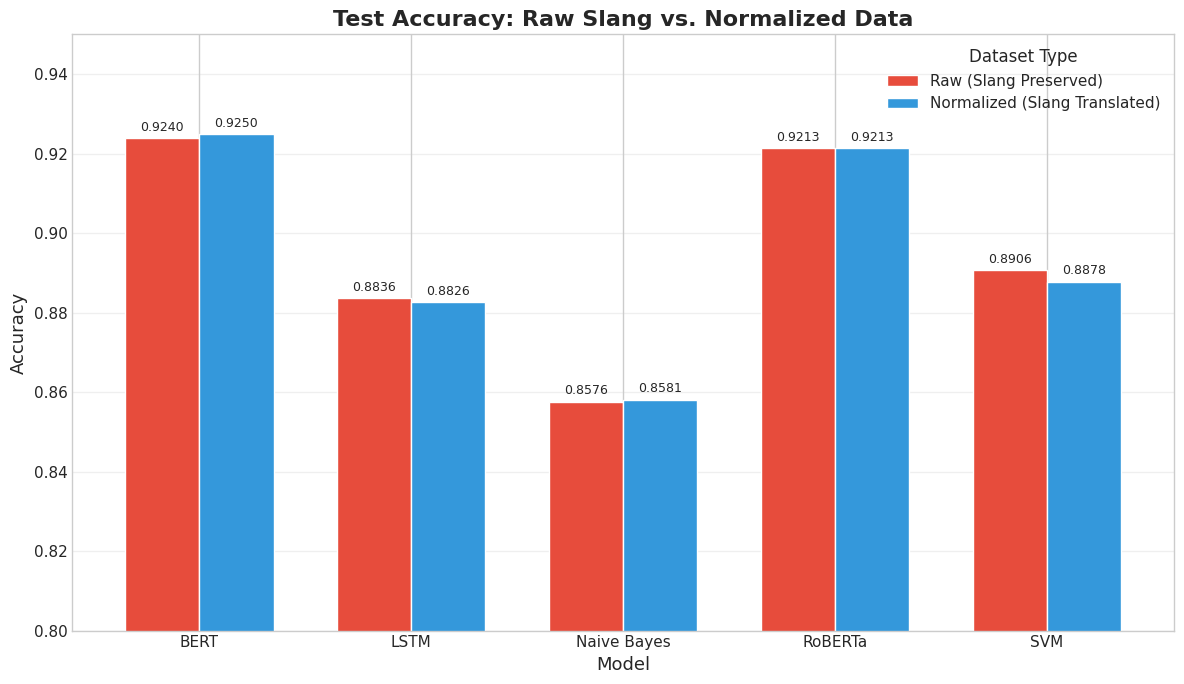

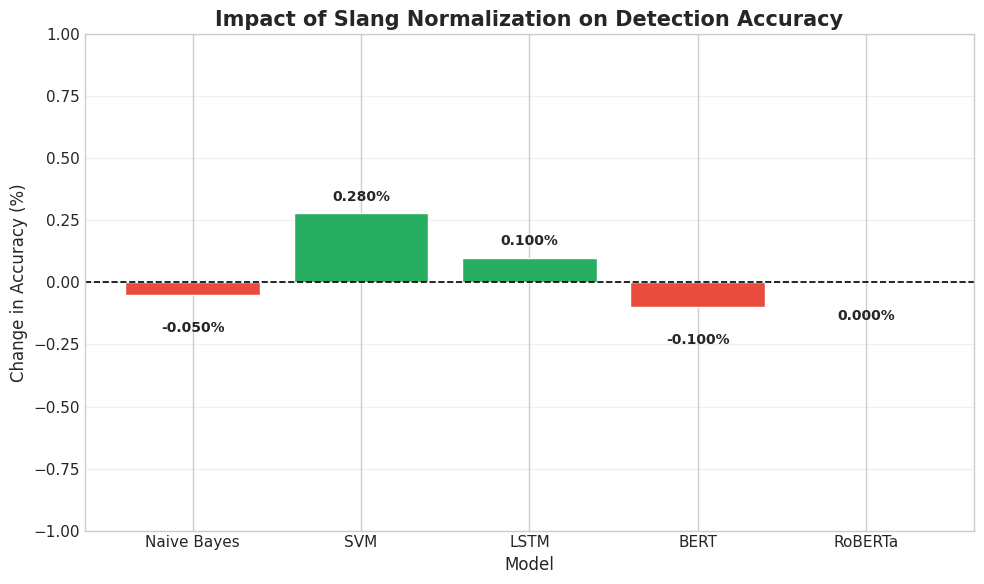

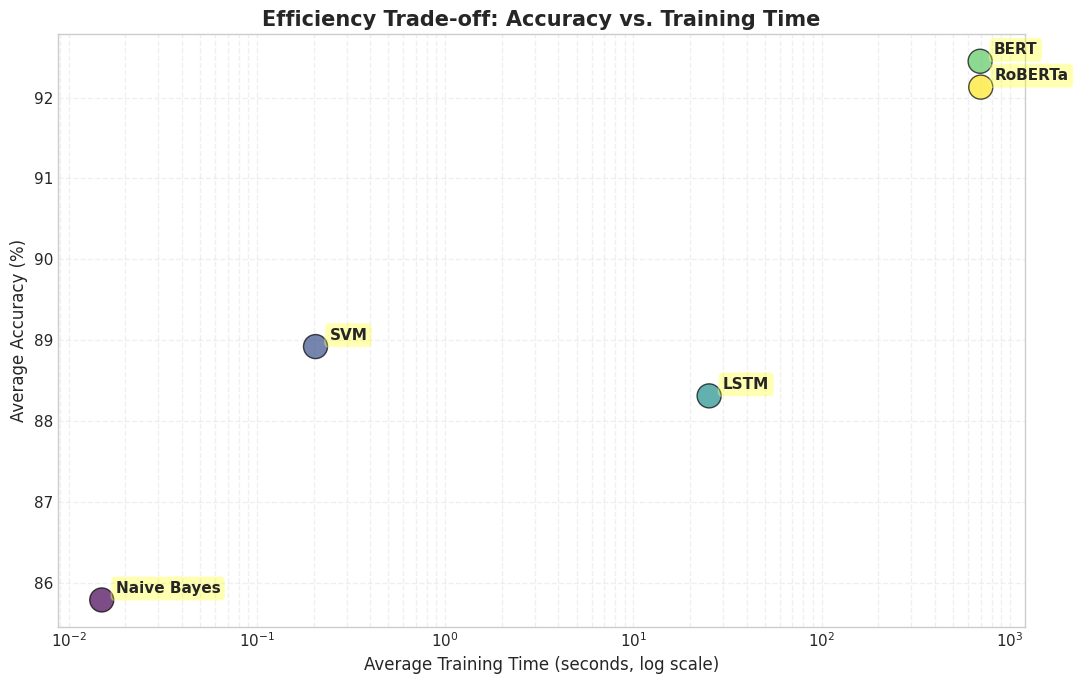

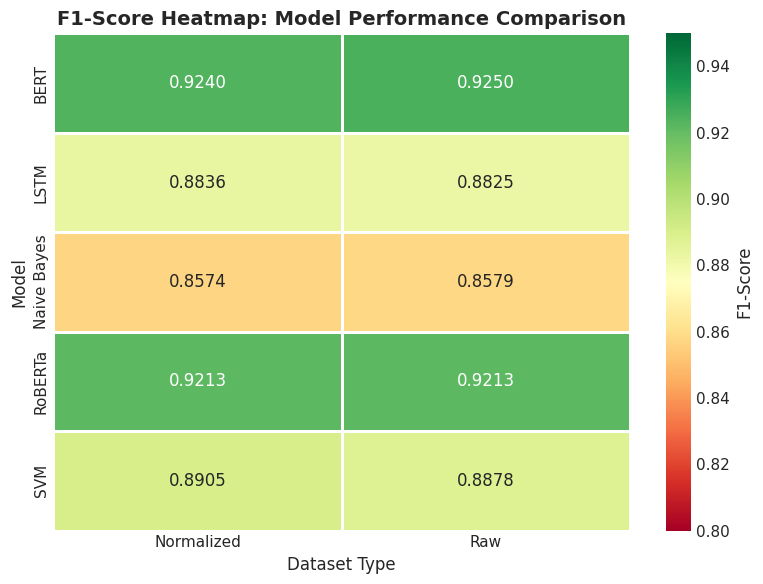


--- SUMMARY STATISTICS ---
         Model  Raw_Accuracy  Norm_Accuracy  Delta_Percent      Winner
0  Naive Bayes        0.8581         0.8576          -0.05         Raw
1          SVM        0.8878         0.8906           0.28  Normalized
2         LSTM        0.8826         0.8836           0.10  Normalized
3         BERT        0.9250         0.9240          -0.10         Raw
4      RoBERTa        0.9213         0.9213           0.00         Tie

📥 Downloading all files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ COMPLETE! You now have:
   - 2 CSV tables
   - 4 publication-ready graphs


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

# ==========================================
# 1. YOUR RESULTS (EXTRACTED FROM OUTPUT)
# ==========================================
data = {
    'Model': ['Naive Bayes', 'Naive Bayes', 'SVM', 'SVM', 'LSTM', 'LSTM', 'BERT', 'BERT', 'RoBERTa', 'RoBERTa'],
    'Dataset': ['Raw', 'Normalized', 'Raw', 'Normalized', 'Raw', 'Normalized', 'Raw', 'Normalized', 'Raw', 'Normalized'],

    # Test Accuracy
    'Test_Accuracy': [0.8581, 0.8576, 0.8878, 0.8906, 0.8826, 0.8836, 0.9250, 0.9240, 0.9213, 0.9213],

    # Training Time (seconds)
    'Training_Time': [0.02, 0.01, 0.24, 0.17, 27.99, 22.56, 696.22, 694.99, 700.92, 701.46],

    # Weighted F1-Score
    'F1_Score': [0.8579, 0.8574, 0.8878, 0.8905, 0.8825, 0.8836, 0.9250, 0.9240, 0.9213, 0.9213],

    # Precision (Weighted)
    'Precision': [0.8615, 0.8612, 0.8878, 0.8905, 0.8826, 0.8839, 0.9250, 0.9241, 0.9213, 0.9213],

    # Recall (Weighted)
    'Recall': [0.8581, 0.8576, 0.8878, 0.8906, 0.8826, 0.8836, 0.9250, 0.9240, 0.9213, 0.9213]
}

df = pd.DataFrame(data)

# ==========================================
# 2. SAVE MASTER TABLE
# ==========================================
csv_filename = 'Final_Results_All_Models.csv'
df.to_csv(csv_filename, index=False)
print("--- MASTER RESULTS TABLE ---")
print(df)
print("\n")

# ==========================================
# 3. GRAPH 1: ACCURACY COMPARISON (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Pivot data for side-by-side bars
df_pivot = df.pivot(index='Model', columns='Dataset', values='Test_Accuracy')

# Create bar plot
ax = df_pivot.plot(kind='bar', color=['#e74c3c', '#3498db'], width=0.7, figsize=(12, 7))

plt.title('Test Accuracy: Raw Slang vs. Normalized Data', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.ylim(0.80, 0.95)
plt.xticks(rotation=0)
plt.legend(title='Dataset Type', labels=['Raw (Slang Preserved)', 'Normalized (Slang Translated)'])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('Graph_1_Accuracy_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. GRAPH 2: DELTA (IMPACT OF NORMALIZATION)
# ==========================================
# Calculate difference (Normalized - Raw)
delta_data = []
for model in ['Naive Bayes', 'SVM', 'LSTM', 'BERT', 'RoBERTa']:
    raw_acc = df[(df['Model'] == model) & (df['Dataset'] == 'Raw')]['Test_Accuracy'].values[0]
    norm_acc = df[(df['Model'] == model) & (df['Dataset'] == 'Normalized')]['Test_Accuracy'].values[0]
    delta = norm_acc - raw_acc
    delta_data.append({'Model': model, 'Delta': delta})

df_delta = pd.DataFrame(delta_data)

plt.figure(figsize=(10, 6))
colors = ['#27ae60' if x >= 0 else '#e74c3c' for x in df_delta['Delta']]
bars = plt.bar(df_delta['Model'], df_delta['Delta'] * 100, color=colors)  # Convert to percentage

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.ylabel('Change in Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.title('Impact of Slang Normalization on Detection Accuracy', fontsize=15, fontweight='bold')
plt.ylim(-1.0, 1.0)

# Add value labels
for bar in bars:
    height = bar.get_height()
    label_y = height + 0.05 if height > 0 else height - 0.15
    plt.text(bar.get_x() + bar.get_width()/2, label_y,
             f'{height:.3f}%', ha='center', fontweight='bold', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Graph_2_Normalization_Impact.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. GRAPH 3: TRAINING EFFICIENCY
# ==========================================
# Get average training time per model
efficiency_data = []
for model in ['Naive Bayes', 'SVM', 'LSTM', 'BERT', 'RoBERTa']:
    avg_time = df[df['Model'] == model]['Training_Time'].mean()
    avg_acc = df[df['Model'] == model]['Test_Accuracy'].mean()
    efficiency_data.append({'Model': model, 'Avg_Time': avg_time, 'Avg_Accuracy': avg_acc})

df_eff = pd.DataFrame(efficiency_data)

plt.figure(figsize=(11, 7))
scatter = plt.scatter(df_eff['Avg_Time'], df_eff['Avg_Accuracy'] * 100,
                     s=300, c=range(len(df_eff)), cmap='viridis', alpha=0.7, edgecolors='black')

plt.xscale('log')
plt.xlabel('Average Training Time (seconds, log scale)', fontsize=12)
plt.ylabel('Average Accuracy (%)', fontsize=12)
plt.title('Efficiency Trade-off: Accuracy vs. Training Time', fontsize=15, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.3)

# Add model labels
for i, row in df_eff.iterrows():
    plt.annotate(row['Model'],
                xy=(row['Avg_Time'], row['Avg_Accuracy'] * 100),
                xytext=(10, 5), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('Graph_3_Efficiency_Tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. GRAPH 4: F1-SCORE HEATMAP
# ==========================================
# Create pivot table for heatmap
heatmap_data = df.pivot(index='Model', columns='Dataset', values='F1_Score')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=1, cbar_kws={'label': 'F1-Score'}, vmin=0.80, vmax=0.95)

plt.title('F1-Score Heatmap: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Model', fontsize=12)
plt.xlabel('Dataset Type', fontsize=12)
plt.tight_layout()
plt.savefig('Graph_4_F1_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 7. SUMMARY STATISTICS TABLE
# ==========================================
summary_stats = df_delta.copy()
summary_stats['Raw_Accuracy'] = [0.8581, 0.8878, 0.8826, 0.9250, 0.9213]
summary_stats['Norm_Accuracy'] = [0.8576, 0.8906, 0.8836, 0.9240, 0.9213]
summary_stats['Delta_Percent'] = summary_stats['Delta'] * 100
summary_stats['Winner'] = summary_stats.apply(
    lambda x: 'Raw' if x['Delta'] < 0 else ('Normalized' if x['Delta'] > 0 else 'Tie'), axis=1
)

print("\n--- SUMMARY STATISTICS ---")
print(summary_stats[['Model', 'Raw_Accuracy', 'Norm_Accuracy', 'Delta_Percent', 'Winner']])

summary_csv = 'Summary_Statistics.csv'
summary_stats.to_csv(summary_csv, index=False)

# ==========================================
# 8. DOWNLOAD ALL FILES
# ==========================================
print("\n📥 Downloading all files...")
files.download(csv_filename)
files.download(summary_csv)
files.download('Graph_1_Accuracy_Comparison.png')
files.download('Graph_2_Normalization_Impact.png')
files.download('Graph_3_Efficiency_Tradeoff.png')
files.download('Graph_4_F1_Heatmap.png')

print("\n✅ COMPLETE! You now have:")
print("   - 2 CSV tables")
print("   - 4 publication-ready graphs")

✅ Generated Table_Comprehensive_Metrics.png


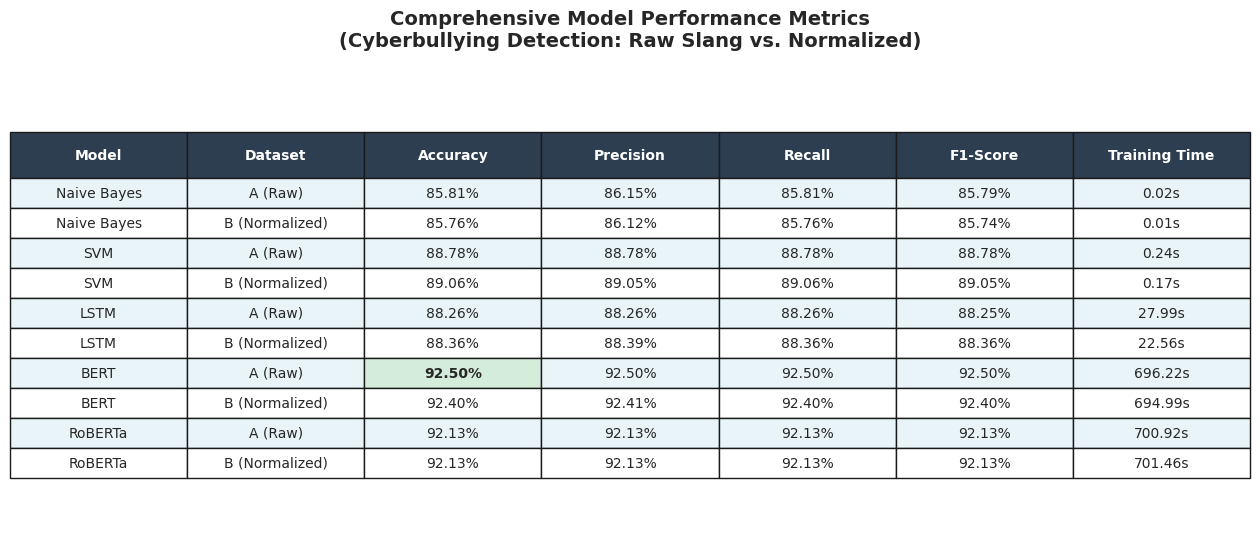

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Generated Table_Summary_Delta_Analysis.png


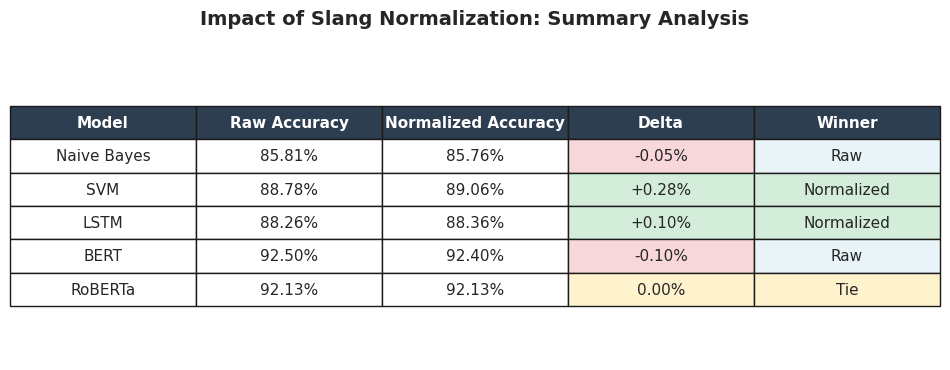

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Generated Table_Class_Level_Metrics.png


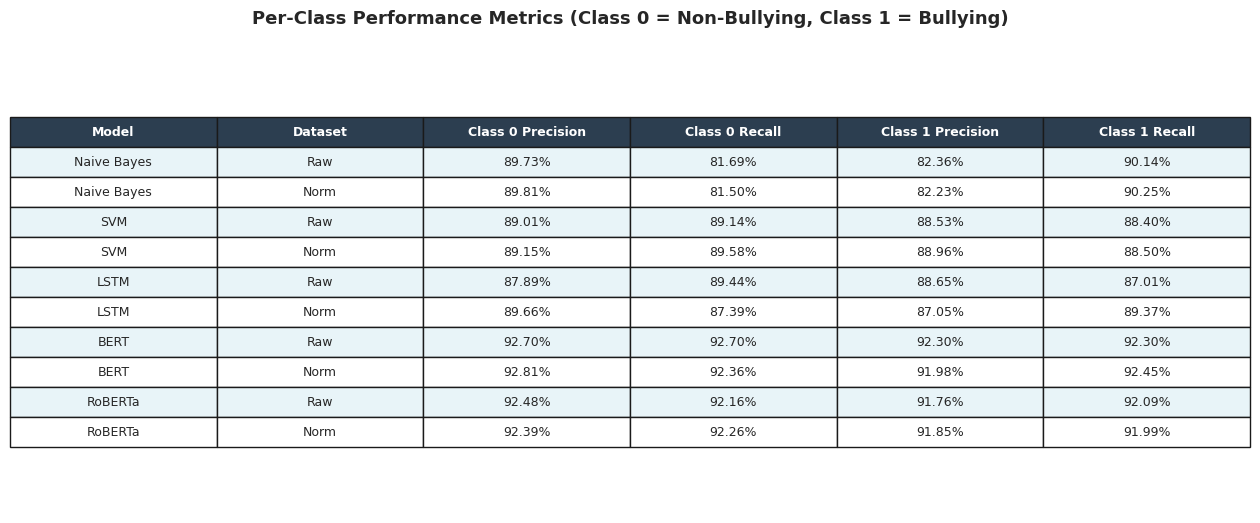

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL TABLES GENERATED!
Downloaded files:
  1. Table_Comprehensive_Metrics.png
  2. Table_Summary_Delta_Analysis.png
  3. Table_Class_Level_Metrics.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# ==========================================
# 1. INPUT THE DATA (YOUR ACTUAL RESULTS)
# ==========================================
data = {
    'Model': [
        'Naive Bayes', 'Naive Bayes',
        'SVM', 'SVM',
        'LSTM', 'LSTM',
        'BERT', 'BERT',
        'RoBERTa', 'RoBERTa'
    ],
    'Dataset': [
        'A (Raw)', 'B (Normalized)',
        'A (Raw)', 'B (Normalized)',
        'A (Raw)', 'B (Normalized)',
        'A (Raw)', 'B (Normalized)',
        'A (Raw)', 'B (Normalized)'
    ],
    'Accuracy': [85.81, 85.76, 88.78, 89.06, 88.26, 88.36, 92.50, 92.40, 92.13, 92.13],
    'Precision': [86.15, 86.12, 88.78, 89.05, 88.26, 88.39, 92.50, 92.41, 92.13, 92.13],
    'Recall': [85.81, 85.76, 88.78, 89.06, 88.26, 88.36, 92.50, 92.40, 92.13, 92.13],
    'F1-Score': [85.79, 85.74, 88.78, 89.05, 88.25, 88.36, 92.50, 92.40, 92.13, 92.13],
    'Training Time': ['0.02s', '0.01s', '0.24s', '0.17s', '27.99s', '22.56s', '696.22s', '694.99s', '700.92s', '701.46s']
}

df = pd.DataFrame(data)

# Add % sign to metric columns for display
df_display = df.copy()
cols_to_format = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for col in cols_to_format:
    df_display[col] = df_display[col].apply(lambda x: f'{x:.2f}%')

# ==========================================
# 2. GENERATE THE TABLE IMAGE
# ==========================================
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Add title
plt.title('Comprehensive Model Performance Metrics\n(Cyberbullying Detection: Raw Slang vs. Normalized)',
          fontsize=14, fontweight='bold', pad=20)

# Create the table
table = ax.table(cellText=df_display.values,
                 colLabels=df_display.columns,
                 cellLoc='center',
                 loc='center')

# ==========================================
# 3. STYLE THE TABLE
# ==========================================
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.8)

for (row, col), cell in table.get_celld().items():
    # Header Styling
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')  # Dark blue header
        cell.set_height(0.1)
    # Row Styling
    else:
        # Alternate colors for Raw vs Normalized
        if df_display.iloc[row-1]['Dataset'] == 'A (Raw)':
            cell.set_facecolor('#e8f4f8')  # Light blue for Raw
        else:
            cell.set_facecolor('#ffffff')  # White for Normalized

        # Highlight best accuracy (BERT Raw = 92.50%)
        if row in [7] and col == 2:  # BERT Raw accuracy
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#d4edda')  # Light green highlight

# ==========================================
# 4. SAVE AND DOWNLOAD
# ==========================================
filename = "Table_Comprehensive_Metrics.png"
plt.savefig(filename, bbox_inches='tight', dpi=300)
print(f"✅ Generated {filename}")
plt.show()

files.download(filename)

# ==========================================
# 5. GENERATE SUMMARY TABLE (Delta Analysis)
# ==========================================
summary_data = {
    'Model': ['Naive Bayes', 'SVM', 'LSTM', 'BERT', 'RoBERTa'],
    'Raw Accuracy': ['85.81%', '88.78%', '88.26%', '92.50%', '92.13%'],
    'Normalized Accuracy': ['85.76%', '89.06%', '88.36%', '92.40%', '92.13%'],
    'Delta': ['-0.05%', '+0.28%', '+0.10%', '-0.10%', '0.00%'],
    'Winner': ['Raw', 'Normalized', 'Normalized', 'Raw', 'Tie']
}

df_summary = pd.DataFrame(summary_data)

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.axis('tight')
ax2.axis('off')

plt.title('Impact of Slang Normalization: Summary Analysis',
          fontsize=14, fontweight='bold', pad=20)

table2 = ax2.table(cellText=df_summary.values,
                   colLabels=df_summary.columns,
                   cellLoc='center',
                   loc='center')

table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1.0, 2.0)

for (row, col), cell in table2.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    else:
        # Color the Delta column based on positive/negative
        if col == 3:  # Delta column
            delta_val = df_summary.iloc[row-1]['Delta']
            if '+' in delta_val:
                cell.set_facecolor('#d4edda')  # Green for improvement
            elif '-' in delta_val:
                cell.set_facecolor('#f8d7da')  # Red for decrease
            else:
                cell.set_facecolor('#fff3cd')  # Yellow for tie

        # Color the Winner column
        if col == 4:  # Winner column
            winner = df_summary.iloc[row-1]['Winner']
            if winner == 'Raw':
                cell.set_facecolor('#e8f4f8')  # Blue for Raw
            elif winner == 'Normalized':
                cell.set_facecolor('#d4edda')  # Green for Normalized
            else:
                cell.set_facecolor('#fff3cd')  # Yellow for Tie

filename2 = "Table_Summary_Delta_Analysis.png"
plt.savefig(filename2, bbox_inches='tight', dpi=300)
print(f"✅ Generated {filename2}")
plt.show()

files.download(filename2)

# ==========================================
# 6. GENERATE CLASS-LEVEL METRICS TABLE
# ==========================================
class_data = {
    'Model': ['Naive Bayes', 'Naive Bayes', 'SVM', 'SVM', 'LSTM', 'LSTM', 'BERT', 'BERT', 'RoBERTa', 'RoBERTa'],
    'Dataset': ['Raw', 'Norm', 'Raw', 'Norm', 'Raw', 'Norm', 'Raw', 'Norm', 'Raw', 'Norm'],
    'Class 0 Precision': ['89.73%', '89.81%', '89.01%', '89.15%', '87.89%', '89.66%', '92.70%', '92.81%', '92.48%', '92.39%'],
    'Class 0 Recall': ['81.69%', '81.50%', '89.14%', '89.58%', '89.44%', '87.39%', '92.70%', '92.36%', '92.16%', '92.26%'],
    'Class 1 Precision': ['82.36%', '82.23%', '88.53%', '88.96%', '88.65%', '87.05%', '92.30%', '91.98%', '91.76%', '91.85%'],
    'Class 1 Recall': ['90.14%', '90.25%', '88.40%', '88.50%', '87.01%', '89.37%', '92.30%', '92.45%', '92.09%', '91.99%']
}

df_class = pd.DataFrame(class_data)

fig3, ax3 = plt.subplots(figsize=(16, 6))
ax3.axis('tight')
ax3.axis('off')

plt.title('Per-Class Performance Metrics (Class 0 = Non-Bullying, Class 1 = Bullying)',
          fontsize=13, fontweight='bold', pad=20)

table3 = ax3.table(cellText=df_class.values,
                   colLabels=df_class.columns,
                   cellLoc='center',
                   loc='center')

table3.auto_set_font_size(False)
table3.set_fontsize(9)
table3.scale(1.0, 1.8)

for (row, col), cell in table3.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    else:
        if df_class.iloc[row-1]['Dataset'] == 'Raw':
            cell.set_facecolor('#e8f4f8')
        else:
            cell.set_facecolor('#ffffff')

filename3 = "Table_Class_Level_Metrics.png"
plt.savefig(filename3, bbox_inches='tight', dpi=300)
print(f"✅ Generated {filename3}")
plt.show()

files.download(filename3)

print("\n" + "="*50)
print("✅ ALL TABLES GENERATED!")
print("="*50)
print("Downloaded files:")
print("  1. Table_Comprehensive_Metrics.png")
print("  2. Table_Summary_Delta_Analysis.png")
print("  3. Table_Class_Level_Metrics.png")

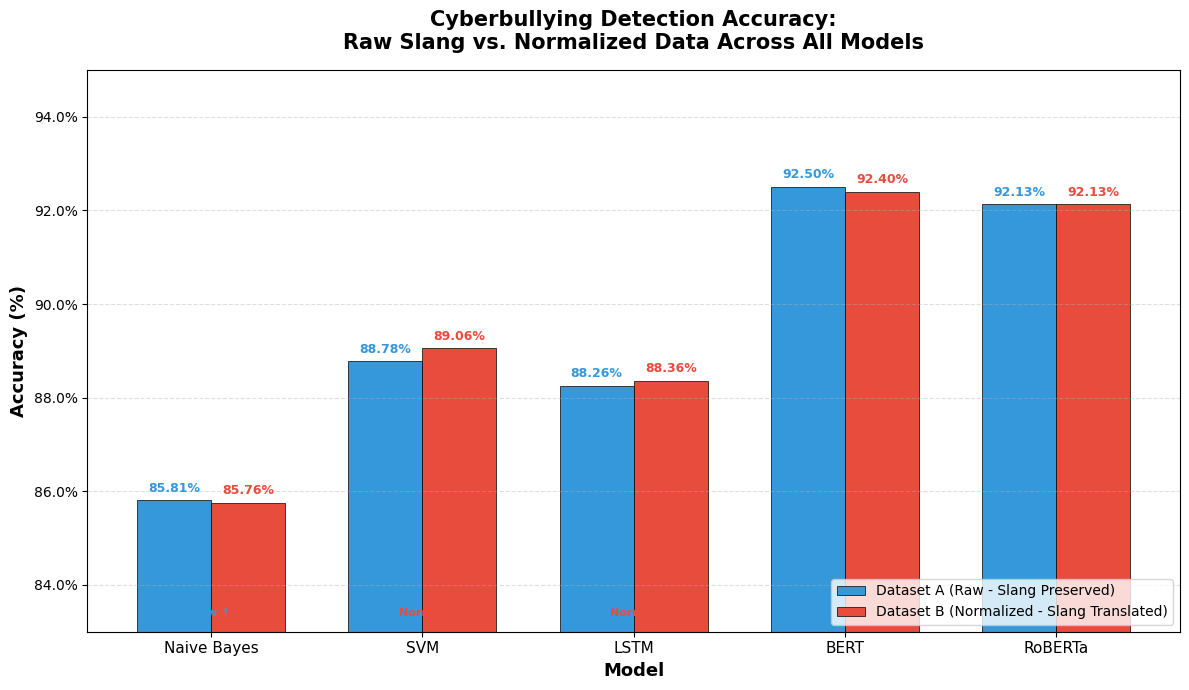

✅ Saved Corrected_Accuracy_Comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# ==========================================
# EXACT DATA FROM YOUR RESULTS
# ==========================================
models = ['Naive Bayes', 'SVM', 'LSTM', 'BERT', 'RoBERTa']

raw_accuracies = [85.81, 88.78, 88.26, 92.50, 92.13]
norm_accuracies = [85.76, 89.06, 88.36, 92.40, 92.13]

# ==========================================
# BAR CHART SETUP
# ==========================================
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Create bars
bars1 = ax.bar(x - width/2, raw_accuracies, width,
               label='Dataset A (Raw - Slang Preserved)',
               color='#3498db',  # Blue for Raw
               edgecolor='black', linewidth=0.5)

bars2 = ax.bar(x + width/2, norm_accuracies, width,
               label='Dataset B (Normalized - Slang Translated)',
               color='#e74c3c',  # Red for Normalized
               edgecolor='black', linewidth=0.5)

# ==========================================
# ADD VALUE LABELS ON TOP OF EACH BAR
# ==========================================
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#3498db')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#e74c3c')

# ==========================================
# FORMATTING
# ==========================================
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Cyberbullying Detection Accuracy:\nRaw Slang vs. Normalized Data Across All Models',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(83, 95)  # Zoomed in to show differences clearly
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# ==========================================
# ADD WINNER ANNOTATIONS BETWEEN BARS
# ==========================================
winners = ['Raw ↑', 'Norm ↑', 'Norm ↑', 'Raw ↑', 'Tie']
winner_colors = ['#3498db', '#e74c3c', '#e74c3c', '#3498db', '#888888']

for i, (winner, color) in enumerate(zip(winners, winner_colors)):
    ax.annotate(winner,
                xy=(x[i], 83.3),
                ha='center', va='bottom',
                fontsize=8, fontweight='bold',
                color=color)

plt.tight_layout()

# ==========================================
# SAVE AND DOWNLOAD
# ==========================================
filename = 'Corrected_Accuracy_Comparison.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved {filename}")
files.download(filename)